# Análisis Estadístico sobre KDE — Multi-Kernel

Este notebook es una versión modificada de `KDE_Estadisticas.ipynb` que reemplaza `scipy.stats.gaussian_kde` por `sklearn.neighbors.KernelDensity` para soportar múltiples tipos de kernel.

**Kernels disponibles:** `gaussian`, `epanechnikov`, `tophat`, `exponential`, `linear`, `cosine`

**Secciones:**
1. Carga de datos y preparación KDE
2. Medidas de tendencia central
3. Área bajo la curva KDE
4. Percentil de corte (densidad < 0.00001)
5. Cuartiles y percentiles (con reporte especial de Q10 y Q90)
6. Desigualdad de Chebyshev
7. Grupos naturales emergentes del KDE
8. Comparación de todos los kernels

## 0) Carga del DataFrame

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

FILE_PATH = str((Path.cwd().parent.parent / "Datos" / "otu_data_converted.csv").resolve())   # Ruta relativa al proyecto

def load_dataframe_from_path(path):
    """
    Carga un DataFrame completo desde un archivo .csv o .otus.
    No filtra columnas.
    Retorna el DataFrame tal cual está en el archivo.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
    elif ext == ".otus":
        df = pd.read_csv(path, sep="\t")  # Formato típico OTU
    else:
        raise ValueError(f"Formato no soportado: {ext}. Usa .csv o .otus")

    return df

df = load_dataframe_from_path(FILE_PATH)
print(f"Archivo cargado: {FILE_PATH}")
print(f"Shape del DataFrame: {df.shape}")
print(f"Columnas: {df.columns.tolist()[:10]}{'...' if len(df.columns) > 10 else ''}")
df.head(5)

Archivo cargado: C:\Users\manue\OneDrive\Escritorio\Clustering_Microbiota\Datos\otu_data_converted.csv
Shape del DataFrame: (441, 4739)
Columnas: ['ID', 'Otu00001', 'Otu00002', 'Otu00003', 'Otu00004', 'Otu00005', 'Otu00006', 'Otu00007', 'Otu00008', 'Otu00009']...


,ID,Otu00001,Otu00002,Otu00003,Otu00004,Otu00005,Otu00006,Otu00007,Otu00008,Otu00009,...,Otu04757,Otu04758,Otu04759,Otu04760,Otu04761,Otu04762,Otu04763,Otu04764,Otu04765,Otu04766
0,MI_001_H,354,817,50,31,448,547,727,353,2,...,0,0,0,0,0,0,0,0,0,0
1,MI_002_H,168,9,131,3005,68,10187,570,2006,104,...,0,0,0,0,0,0,0,0,0,0
2,MI_003_H,19,174,6211,79,1063,0,6077,1852,1471,...,0,0,0,0,0,0,0,0,0,0
3,MI_004_H,264,1816,159,16,110,4,12,206,0,...,0,0,0,0,0,0,0,0,0,0
4,MI_005_H,0,2,0,12,598,39,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 0.5) Selección del Ancho de Banda (Bandwidth)

Identifica el mejor `bw_method` antes de calcular el KDE.

- **`"auto"`** → Cross-validation de log-verosimilitud sobre una malla de bandwidths (usando el kernel seleccionado).
- **`"scott"` / `"silverman"`** → Reglas automáticas clásicas (calculadas como referencia con scipy, aplicadas como ancho de banda absoluto).
- **Número fijo** → Usar directamente como ancho de banda absoluto (ej. `150.0`).

Al final de la celda se imprime el `bw_final` que se usará en el bloque KDE.

In [2]:
# =========================================
# SELECCI?N DE ANCHO DE BANDA ?PTIMO
# Modificado para soportar m?ltiples kernels usando sklearn
# =========================================

# --- GPU setup ---
USE_GPU = True

import os
from pathlib import Path


def _prepare_cuda_windows():
    """Normaliza CUDA_PATH y registra DLLs para CuPy en Windows."""
    cuda_root = os.environ.get("CUDA_PATH") or os.environ.get("CUDA_PATH_V13_1")
    if not cuda_root:
        return None

    cuda_root = Path(cuda_root)
    if cuda_root.name.lower() == "bin":
        cuda_root = cuda_root.parent

    bin_dir = cuda_root / "bin"
    x64_dir = bin_dir / "x64"
    if not bin_dir.exists():
        raise FileNotFoundError(f"No existe la carpeta CUDA bin: {bin_dir}")

    os.environ["CUDA_PATH"] = str(cuda_root)
    os.add_dll_directory(str(bin_dir))
    if x64_dir.exists():
        os.add_dll_directory(str(x64_dir))
    return cuda_root


_gpu_ok = False
if USE_GPU:
    try:
        _cuda_root = _prepare_cuda_windows()
        if _cuda_root is not None:
            print(f"CUDA_PATH normalizado: {_cuda_root}")

        import cupy as cp
        n_dev = cp.cuda.runtime.getDeviceCount()
        if n_dev == 0:
            raise RuntimeError("No GPUs detected.")
        free_mem, total_mem = cp.cuda.Device(0).mem_info
        print(f"GPU disponible: {n_dev} dispositivo(s)")
        print(f"  Memoria: {free_mem/1e9:.1f} GB libres / {total_mem/1e9:.1f} GB totales")

        _probe = cp.arange(1, dtype=cp.float64)
        _ = cp.asnumpy(_probe + 1.0)
        _gpu_ok = True
    except ImportError:
        print("CuPy no encontrado. Instalalo con: pip install cupy-cuda13x")
        print("Usando CPU.")
    except Exception as e:
        print(f"GPU no disponible ({e}). Usando CPU.")
else:
    print("Modo CPU (USE_GPU=False).")
print(f"Backend activo: {'GPU (CuPy)' if _gpu_ok else 'CPU (NumPy/SciPy)'}")


CUDA_PATH normalizado: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1


GPU disponible: 1 dispositivo(s)
  Memoria: 7.4 GB libres / 8.6 GB totales


Backend activo: GPU (CuPy)


Kernel seleccionado: epanechnikov
Datos: N = 105,420  |  std = 895.1
Scott     : bw = 88.57
Silverman : bw = 93.81

CV con kernel='epanechnikov', 10,000 puntos, 5-fold...


Mejor bw (CV): 4.42837

  KERNEL: epanechnikov
  bw     = 4.42837
  Fuente : CV (epanechnikov)


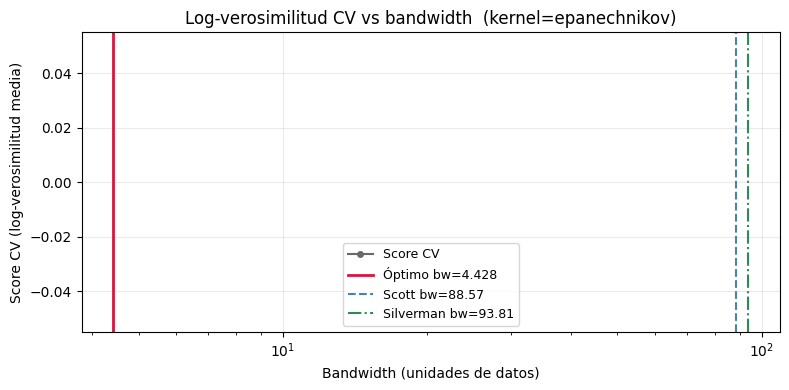

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy.stats import gaussian_kde  # solo para calcular valores de referencia Scott/Silverman
from scipy.integrate import quad

# ========================================
# PARÁMETROS PRINCIPALES
# ========================================
KERNEL = "epanechnikov"   # 'gaussian' | 'epanechnikov' | 'tophat' | 'exponential' | 'linear' | 'cosine'

_bw_selector     = "auto"   # "auto" | "scott" | "silverman" | número fijo
_usar_solo_pos   = True
_usar_log_x      = True
_n_muestra_cv    = 10000
_n_grid_cv       = 50
_cv_folds        = 5
_bw_malla_log    = True
_bw_rango        = (0.05, 10.0)
_mostrar_grafico = True

# ============================================================
# Preparar datos
# ============================================================
_df_num_bw = df.select_dtypes(include=[np.number])
_vals_bw   = _df_num_bw.to_numpy(dtype=float).ravel()
_vals_bw   = _vals_bw[np.isfinite(_vals_bw)]
_vals_pos  = _vals_bw[_vals_bw > 0]
if _usar_log_x:
    _usar_solo_pos = True
_data_bw = _vals_pos if _usar_solo_pos else _vals_bw
if len(_data_bw) == 0:
    raise ValueError("No hay datos.")

_n   = len(_data_bw)
_std = float(np.std(_data_bw, ddof=1))

# Reference bw values from scipy (Scott/Silverman) in absolute units
_kde_scott_ref = gaussian_kde(_data_bw, bw_method="scott")
_kde_silv_ref  = gaussian_kde(_data_bw, bw_method="silverman")
_bw_scott_abs     = float(_kde_scott_ref.factor * _std)
_bw_silverman_abs = float(_kde_silv_ref.factor  * _std)

print(f"Kernel seleccionado: {KERNEL}")
print(f"Datos: N = {_n:,}  |  std = {_std:.4g}")
print(f"Scott     : bw = {_bw_scott_abs:.4g}")
print(f"Silverman : bw = {_bw_silverman_abs:.4g}")

# ============================================================
# Cross-validation con sklearn (soporta todos los kernels)
# ============================================================
_bw_opt_abs = None
_cv_scores  = None
_bw_grid_cv = None

if _bw_selector == "auto":
    rng_bw = np.random.default_rng(42)
    if _n_muestra_cv is not None and _n > _n_muestra_cv:
        _idx_cv  = rng_bw.choice(_n, _n_muestra_cv, replace=False)
        _data_cv = _data_bw[_idx_cv]
    else:
        _data_cv = _data_bw

    _bw_min_cv = _bw_scott_abs * _bw_rango[0]
    _bw_max_cv = _bw_scott_abs * _bw_rango[1]
    if _bw_malla_log:
        _bw_grid_cv = np.logspace(np.log10(_bw_min_cv), np.log10(_bw_max_cv), _n_grid_cv)
    else:
        _bw_grid_cv = np.linspace(_bw_min_cv, _bw_max_cv, _n_grid_cv)

    print(f"\nCV con kernel='{KERNEL}', {len(_data_cv):,} puntos, {_cv_folds}-fold...")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _gs = GridSearchCV(
            KernelDensity(kernel=KERNEL),
            param_grid={"bandwidth": _bw_grid_cv},
            cv=_cv_folds, n_jobs=1
        )
        _gs.fit(_data_cv.reshape(-1, 1))

    _bw_opt_abs = float(_gs.best_params_["bandwidth"])
    _cv_scores  = _gs.cv_results_["mean_test_score"]
    print(f"Mejor bw (CV): {_bw_opt_abs:.6g}")

# ============================================================
# Decidir bw final
# ============================================================
if isinstance(_bw_selector, (int, float)):
    _bw_final = float(_bw_selector)
    _bw_fuente = "fijo"
elif _bw_selector == "scott":
    _bw_final = _bw_scott_abs
    _bw_fuente = "Scott"
elif _bw_selector == "silverman":
    _bw_final = _bw_silverman_abs
    _bw_fuente = "Silverman"
else:
    _bw_final  = _bw_opt_abs
    _bw_fuente = f"CV ({KERNEL})"

print(f"\n{'='*55}")
print(f"  KERNEL: {KERNEL}")
print(f"  bw     = {_bw_final:.6g}")
print(f"  Fuente : {_bw_fuente}")
print(f"{'='*55}")

# ============================================================
# Visualización comparativa (CV score curve)
# ============================================================
if _mostrar_grafico and _bw_selector == "auto" and _bw_grid_cv is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(_bw_grid_cv, _cv_scores, "o-", color="dimgray", markersize=4, linewidth=1.5, label="Score CV")
    ax.axvline(_bw_opt_abs,     color="crimson",   linestyle="-",  linewidth=2,
               label=f"Óptimo bw={_bw_opt_abs:.4g}")
    ax.axvline(_bw_scott_abs,   color="steelblue", linestyle="--", linewidth=1.5,
               label=f"Scott bw={_bw_scott_abs:.4g}")
    ax.axvline(_bw_silverman_abs, color="seagreen", linestyle="-.", linewidth=1.5,
               label=f"Silverman bw={_bw_silverman_abs:.4g}")
    if _bw_malla_log:
        ax.set_xscale("log")
    ax.set_title(f"Log-verosimilitud CV vs bandwidth  (kernel={KERNEL})")
    ax.set_xlabel("Bandwidth (unidades de datos)")
    ax.set_ylabel("Score CV (log-verosimilitud media)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

## 1) Preparación de datos y KDE

Se usa `sklearn.neighbors.KernelDensity` con el kernel seleccionado en `KERNEL`. La evaluación se acelera con GPU (CuPy) si está disponible.

Kernel: epanechnikov  |  bw = 4.42837
N = 105420, min=1, max=6.071e+04


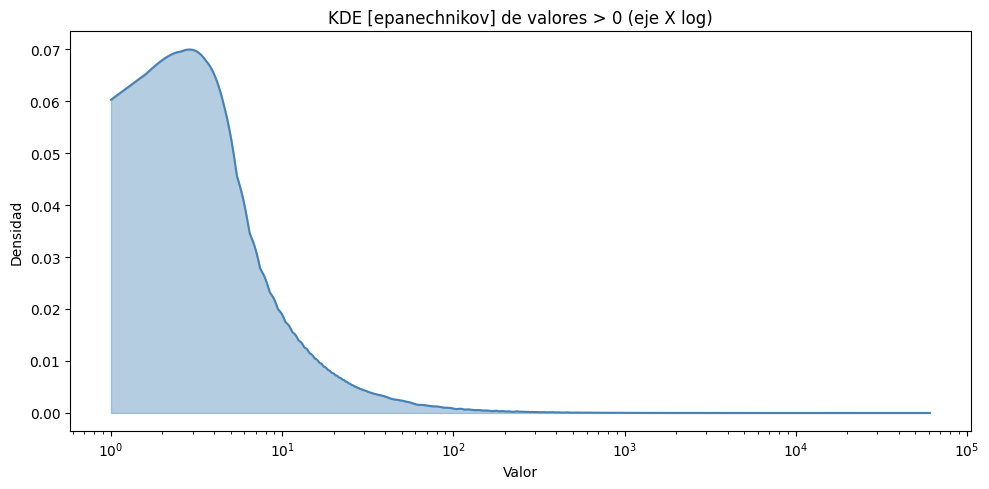

In [4]:
# =========================================
# KDE con kernel seleccionado (sklearn)
# =========================================
usar_solo_positivos = True
usar_escala_log_x   = True
bw_method = _bw_final   # bandwidth en unidades absolutas
cut = 0
figsize = (10, 5)

df_num  = df.select_dtypes(include=[np.number])
valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]
valores_pos = valores[valores > 0]
if usar_escala_log_x:
    usar_solo_positivos = True
data_kde = valores_pos if usar_solo_positivos else valores

print(f"Kernel: {KERNEL}  |  bw = {bw_method:.6g}")
print(f"N = {len(data_kde)}, min={data_kde.min():.4g}, max={data_kde.max():.4g}")

# Crear objeto KDE con sklearn
kde_obj = KernelDensity(kernel=KERNEL, bandwidth=bw_method)
kde_obj.fit(data_kde.reshape(-1, 1))

# Función de evaluación (GPU si disponible, CPU fallback)
if _gpu_ok:
    import cupy as cp
    _data_gpu_kde = cp.asarray(data_kde, dtype=cp.float64)
    _n_data_kde   = len(_data_gpu_kde)
    _bw_gpu       = float(bw_method)

    def _KERNEL_FN(u_gpu):
        """Evalúa el kernel seleccionado (GPU)."""
        if KERNEL == "gaussian":
            return cp.exp(-0.5 * u_gpu**2) / cp.sqrt(2 * np.pi)
        elif KERNEL == "epanechnikov":
            mask = cp.abs(u_gpu) <= 1
            return cp.where(mask, 0.75 * (1 - u_gpu**2), 0.0)
        elif KERNEL == "tophat":
            return cp.where(cp.abs(u_gpu) <= 1, 0.5, 0.0)
        elif KERNEL == "exponential":
            return 0.5 * cp.exp(-cp.abs(u_gpu))
        elif KERNEL == "linear":
            mask = cp.abs(u_gpu) <= 1
            return cp.where(mask, 1.0 - cp.abs(u_gpu), 0.0)
        elif KERNEL == "cosine":
            mask = cp.abs(u_gpu) <= 1
            return cp.where(mask, (np.pi/4) * cp.cos((np.pi/2) * u_gpu), 0.0)
        else:
            raise ValueError(f"Kernel no soportado en GPU: {KERNEL}")

    _free_mem_kde, _ = cp.cuda.Device(0).mem_info
    _chunk_kde = max(100, min(10_000, int(_free_mem_kde * 0.25 / (_n_data_kde * 8))))

    def eval_kde(x_eval):
        x_gpu = cp.asarray(x_eval, dtype=cp.float64)
        y_out = cp.empty(len(x_gpu), dtype=cp.float64)
        for i in range(0, len(x_gpu), _chunk_kde):
            xc   = x_gpu[i:i+_chunk_kde]
            diff = xc[:, None] - _data_gpu_kde[None, :]
            u    = diff / _bw_gpu
            y_out[i:i+_chunk_kde] = cp.sum(_KERNEL_FN(u), axis=1) / (_n_data_kde * _bw_gpu)
        return cp.asnumpy(y_out)
else:
    def eval_kde(x_eval):
        return np.exp(kde_obj.score_samples(x_eval.reshape(-1, 1)))

# Malla de evaluación
if usar_escala_log_x:
    x_grid = np.logspace(np.log10(data_kde.min()), np.log10(data_kde.max()), 10000)
else:
    x_grid = np.linspace(data_kde.min(), data_kde.max(), 10000)

y_grid = eval_kde(x_grid)

# Gráfico
fig, ax = plt.subplots(figsize=figsize)
ax.fill_between(x_grid, y_grid, alpha=0.4, color="steelblue")
ax.plot(x_grid, y_grid, color="steelblue", linewidth=1.5)
if usar_escala_log_x:
    ax.set_xscale("log")
titulo = f"KDE [{KERNEL}] de valores > 0" + (" (eje X log)" if usar_escala_log_x else "")
ax.set_title(titulo)
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

## 2) Medidas de Tendencia Central

- **Media**: promedio aritmético de los datos.
- **Mediana**: valor que divide la distribución al 50%.
- **Moda KDE**: punto de máxima densidad estimada por el KDE.

  MEDIDAS DE TENDENCIA CENTRAL
  Media      : 139.921
  Mediana    : 8
  Moda (KDE) : 2.87265


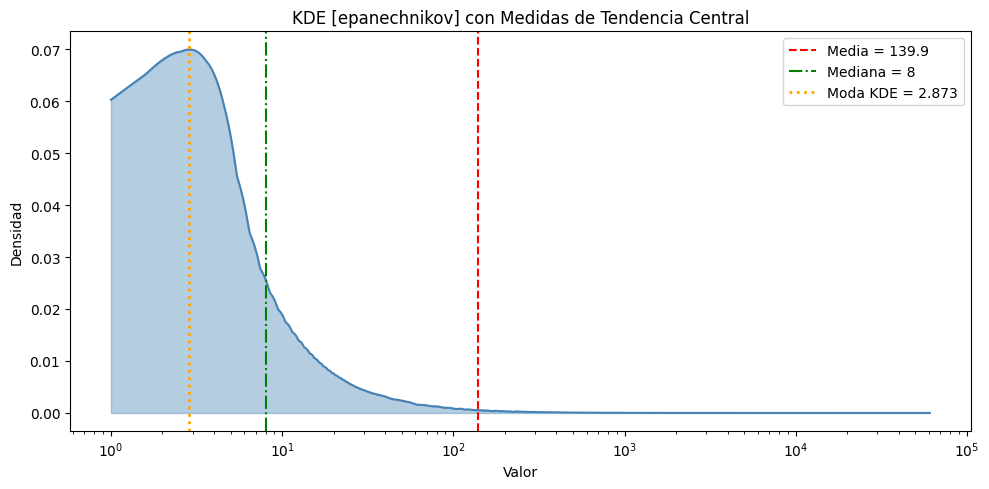

In [5]:
# =========================================
# 2) Medidas de Tendencia Central
# =========================================

media    = float(np.mean(data_kde))
mediana  = float(np.median(data_kde))
moda_kde = float(x_grid[np.argmax(y_grid)])   # punto de máxima densidad en el KDE

print("=" * 45)
print("  MEDIDAS DE TENDENCIA CENTRAL")
print("=" * 45)
print(f"  Media      : {media:.6g}")
print(f"  Mediana    : {mediana:.6g}")
print(f"  Moda (KDE) : {moda_kde:.6g}")
print("=" * 45)

# Visualización con líneas verticales sobre el KDE
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(x_grid, y_grid, alpha=0.4, color="steelblue", label="_nolegend_")
ax.plot(x_grid, y_grid, color="steelblue", linewidth=1.5)

ax.axvline(media,    color="red",    linestyle="--", linewidth=1.5, label=f"Media = {media:.4g}")
ax.axvline(mediana,  color="green",  linestyle="-.", linewidth=1.5, label=f"Mediana = {mediana:.4g}")
ax.axvline(moda_kde, color="orange", linestyle=":",  linewidth=2,   label=f"Moda KDE = {moda_kde:.4g}")

if usar_escala_log_x:
    ax.set_xscale("log")

ax.set_title(f"KDE [{KERNEL}] con Medidas de Tendencia Central")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()

## 3) Área Bajo la Curva KDE

El KDE tiene soporte que puede extenderse más allá del rango `[min, max]` de los datos (dependiendo del kernel). Para kernels de soporte compacto (`tophat`, `epanechnikov`, `linear`, `cosine`) la integral es exactamente la malla extendida. Para `gaussian` y `exponential` las colas se extienden al infinito.

**Estrategia de corrección:**
- Se extiende la malla `N_TAILS` anchos de banda más allá de los datos en ambos extremos.
- Se usa `scipy.integrate.quad` sobre la función `eval_kde` para la integral numérica.

C:\Users\manue\AppData\Local\Temp\ipykernel_22084\879871990.py:33: IntegrationWarning: The maximum number of subdivisions (300) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  area_exacta, area_err = quad(lambda x: float(eval_kde(np.array([x]))[0]), x_lo_ext, x_hi_ext, limit=300)


  ÁREA BAJO LA CURVA KDE
  Kernel                       : epanechnikov
  Ancho de banda (bw_std)      : 4.428
  Rango original               : [1, 6.071e+04]
  Rango extendido (±6·bw)     : [0.001, 6.074e+04]

  Área SIN extender colas      : 0.86983864  (pérdida = 13.02%)
  Área malla extendida         : 0.92414245  (pérdida = 7.59%)
  Área exacta (quad)           : 0.92328189  (error est. = 1.70e-03)

  Valor teórico esperado       : 1.00000000
  Desviación quad vs teórico   : 7.67e-02


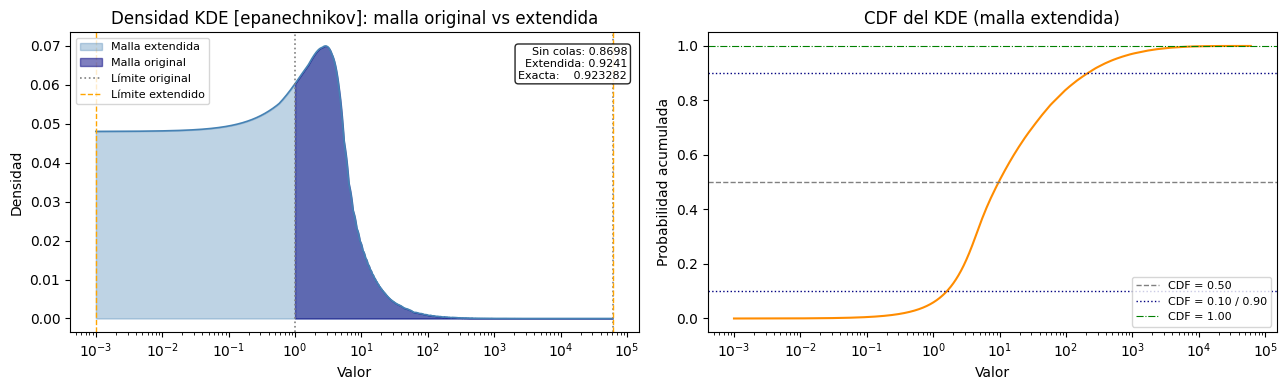

In [6]:
# =========================================
# 3) Área Bajo la Curva KDE
# =========================================
from scipy.integrate import quad

# -----------------------------
# A) Extender la malla para cubrir las colas
# -----------------------------
N_TAILS = 6   # número de anchos de banda a añadir en cada cola

# bw_method ya está en unidades absolutas de x
bw_std = bw_method

x_lo_ext = data_kde.min() - N_TAILS * bw_std
x_hi_ext = data_kde.max() + N_TAILS * bw_std

# Si los datos son positivos con escala log, el límite inferior no puede ser <= 0
if usar_escala_log_x or usar_solo_positivos:
    x_lo_ext = max(x_lo_ext, data_kde.min() * 1e-3)  # mínimo: 0.1% del mínimo de los datos

# Malla extendida para visualización y CDF
if usar_escala_log_x:
    x_grid_ext = np.logspace(np.log10(x_lo_ext), np.log10(x_hi_ext), 20000)
else:
    x_grid_ext = np.linspace(x_lo_ext, x_hi_ext, 20000)

y_grid_ext = eval_kde(x_grid_ext)

# -----------------------------
# B) Área por trapecio (malla extendida) vs integral numérica
# -----------------------------
area_malla    = float(np.trapezoid(y_grid_ext, x_grid_ext))
area_exacta, area_err = quad(lambda x: float(eval_kde(np.array([x]))[0]), x_lo_ext, x_hi_ext, limit=300)

# Área original (sin extensión de colas) para mostrar la pérdida
area_sin_colas = float(np.trapezoid(y_grid, x_grid))

print("=" * 58)
print("  ÁREA BAJO LA CURVA KDE")
print("=" * 58)
print(f"  Kernel                       : {KERNEL}")
print(f"  Ancho de banda (bw_std)      : {bw_std:.4g}")
print(f"  Rango original               : [{x_grid.min():.4g}, {x_grid.max():.4g}]")
print(f"  Rango extendido (±{N_TAILS}·bw)     : [{x_lo_ext:.4g}, {x_hi_ext:.4g}]")
print()
print(f"  Área SIN extender colas      : {area_sin_colas:.8f}  (pérdida = {1-area_sin_colas:.2%})")
print(f"  Área malla extendida         : {area_malla:.8f}  (pérdida = {1-area_malla:.2%})")
print(f"  Área exacta (quad)           : {area_exacta:.8f}  (error est. = {area_err:.2e})")
print()
print(f"  Valor teórico esperado       : 1.00000000")
print(f"  Desviación quad vs teórico   : {abs(1.0 - area_exacta):.2e}")
print("=" * 58)

# -----------------------------
# C) CDF del KDE (sobre malla extendida)
# -----------------------------
dx_ext  = np.diff(x_grid_ext, prepend=x_grid_ext[0])
cdf_kde = np.cumsum(y_grid_ext * dx_ext)
# Normalizar usando el área para que CDF(max) = 1
cdf_kde = cdf_kde / max(area_exacta, area_malla)

# -----------------------------
# D) Visualización
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Izquierda: densidad — malla original vs extendida
axes[0].fill_between(x_grid_ext, y_grid_ext, alpha=0.35, color="steelblue", label="Malla extendida")
axes[0].fill_between(x_grid, y_grid, alpha=0.5, color="navy", label="Malla original")
axes[0].plot(x_grid_ext, y_grid_ext, linewidth=1.2, color="steelblue")

# Marcar los límites de extensión
axes[0].axvline(x_grid.min(), color="gray",   linestyle=":",  linewidth=1.2, label="Límite original")
axes[0].axvline(x_grid.max(), color="gray",   linestyle=":",  linewidth=1.2)
axes[0].axvline(x_lo_ext,     color="orange", linestyle="--", linewidth=1,   label="Límite extendido")
axes[0].axvline(x_hi_ext,     color="orange", linestyle="--", linewidth=1)

axes[0].text(0.98, 0.95,
             f"Sin colas: {area_sin_colas:.4f}\nExtendida: {area_malla:.4f}\nExacta:    {area_exacta:.6f}",
             ha="right", va="top", transform=axes[0].transAxes, fontsize=8,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

if usar_escala_log_x:
    axes[0].set_xscale("log")
axes[0].set_title(f"Densidad KDE [{KERNEL}]: malla original vs extendida")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=8)

# Derecha: CDF del KDE (malla extendida)
axes[1].plot(x_grid_ext, cdf_kde, linewidth=1.5, color="darkorange")
axes[1].axhline(0.5, color="gray",  linestyle="--", linewidth=1,   label="CDF = 0.50")
axes[1].axhline(0.1, color="navy",  linestyle=":",  linewidth=1,   label="CDF = 0.10 / 0.90")
axes[1].axhline(0.9, color="navy",  linestyle=":",  linewidth=1)
axes[1].axhline(1.0, color="green", linestyle="-.", linewidth=0.8, label="CDF = 1.00")

if usar_escala_log_x:
    axes[1].set_xscale("log")
axes[1].set_title("CDF del KDE (malla extendida)")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5) Cuartiles y Percentiles

Cálculo empírico sobre `data_kde` con reporte especial de **Q10** y **Q90**.

  CUARTILES Y PERCENTILES
  Q10  (P10)  =  1  <<
  Q25  (P25)  =  2
  Q50  (P50)  =  8
  Q75  (P75)  =  38
  Q90  (P90)  =  189  <<
--------------------------------------------------
  IQR (Q75 - Q25)    =  36
  Rango intercuartil (Q10–Q90): [1, 189]


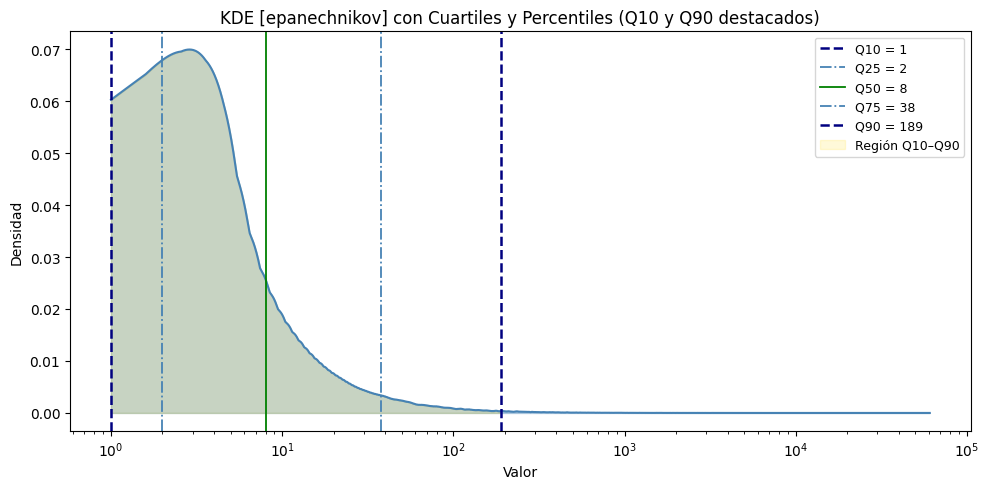

In [7]:
# =========================================
# 5) Cuartiles y Percentiles
# =========================================

niveles = [10, 25, 50, 75, 90]
percentiles = np.percentile(data_kde, niveles)

Q10, Q25, Q50, Q75, Q90 = percentiles
IQR = Q75 - Q25

print("=" * 50)
print("  CUARTILES Y PERCENTILES")
print("=" * 50)
for nivel, valor in zip(niveles, percentiles):
    etiqueta = f"Q{nivel}"
    destaca  = "  <<" if nivel in (10, 90) else ""
    print(f"  {etiqueta:<4} (P{nivel:02d})  =  {valor:.6g}{destaca}")
print("-" * 50)
print(f"  IQR (Q75 - Q25)    =  {IQR:.6g}")
print(f"  Rango intercuartil (Q10–Q90): [{Q10:.4g}, {Q90:.4g}]")
print("=" * 50)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(x_grid, y_grid, alpha=0.35, color="steelblue", label="_nolegend_")
ax.plot(x_grid, y_grid, color="steelblue", linewidth=1.5)

colores = {10: "navy", 25: "steelblue", 50: "green", 75: "steelblue", 90: "navy"}
estilos = {10: "--",    25: "-.",        50: "-",     75: "-.",        90: "--"}

for nivel, valor in zip(niveles, percentiles):
    label = f"Q{nivel} = {valor:.4g}"
    ax.axvline(valor, color=colores[nivel], linestyle=estilos[nivel],
               linewidth=1.8 if nivel in (10, 90) else 1.3, label=label)

# Sombrear región Q10–Q90
mascara_rango = (x_grid >= Q10) & (x_grid <= Q90)
ax.fill_between(x_grid, y_grid, where=mascara_rango,
                alpha=0.15, color="gold", label="Región Q10–Q90")

if usar_escala_log_x:
    ax.set_xscale("log")

ax.set_title(f"KDE [{KERNEL}] con Cuartiles y Percentiles (Q10 y Q90 destacados)")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6) Desigualdad de Chebyshev

La desigualdad de Chebyshev establece que para **cualquier** distribución con media finita $\mu$ y varianza finita $\sigma^2$:

$$P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2} \quad \forall\, k > 1$$

Se compara la **cota teórica** $1/k^2$ contra la **proporción empírica** observada en los datos.

  DESIGUALDAD DE CHEBYSHEV
  mu = 139.921  |  sigma = 895.074  |  N = 105420
      k            mu ± k*sigma     Cota 1/k²    Prop. empírica   Cumple?
----------------------------------------------------------------------
    1.0          [-755.2, 1035]      1.000000          0.025877        SI
    1.5           [-1203, 1483]      0.444444          0.018365        SI
    2.0           [-1650, 1930]      0.250000          0.014020        SI
    2.5           [-2098, 2378]      0.160000          0.010928        SI
    3.0           [-2545, 2825]      0.111111          0.008822        SI
    4.0           [-3440, 3720]      0.062500          0.006194        SI
    5.0           [-4335, 4615]      0.040000          0.004714        SI

  Nota: 'Cumple' indica que la proporción empírica de datos
  fuera del intervalo [mu - k*sigma, mu + k*sigma] está por
  debajo de la cota teórica 1/k² (la desigualdad se verifica).


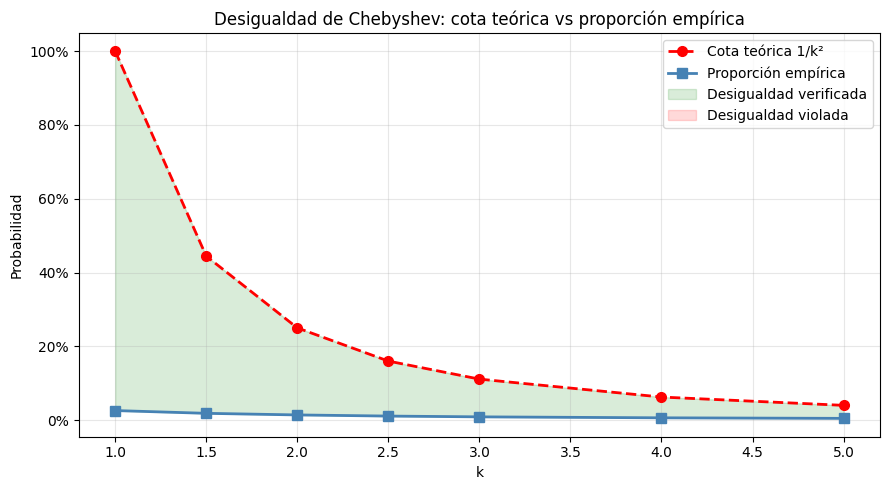

In [8]:
# =========================================
# 6) Desigualdad de Chebyshev
# =========================================
import matplotlib.ticker as ticker

mu    = float(np.mean(data_kde))
sigma = float(np.std(data_kde, ddof=1))

ks = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

print("=" * 70)
print("  DESIGUALDAD DE CHEBYSHEV")
print(f"  mu = {mu:.6g}  |  sigma = {sigma:.6g}  |  N = {len(data_kde)}")
print("=" * 70)
print(f"  {'k':>5}  {'mu ± k*sigma':>22}  {'Cota 1/k²':>12}  {'Prop. empírica':>16}  {'Cumple?':>8}")
print("-" * 70)

filas = []
for k in ks:
    cota_teorica   = 1.0 / k**2
    n_fuera        = int(np.sum(np.abs(data_kde - mu) >= k * sigma))
    prop_empirica  = n_fuera / len(data_kde)
    cumple         = prop_empirica <= cota_teorica
    lo, hi         = mu - k * sigma, mu + k * sigma
    intervalo      = f"[{lo:.4g}, {hi:.4g}]"
    print(f"  {k:>5.1f}  {intervalo:>22}  {cota_teorica:>12.6f}  {prop_empirica:>16.6f}  {'SI' if cumple else 'NO':>8}")
    filas.append(dict(k=k, cota_teorica=cota_teorica,
                      prop_empirica=prop_empirica, cumple=cumple))

print("=" * 70)
print()
print("  Nota: 'Cumple' indica que la proporción empírica de datos")
print("  fuera del intervalo [mu - k*sigma, mu + k*sigma] está por")
print("  debajo de la cota teórica 1/k² (la desigualdad se verifica).")

# Visualización
ks_arr    = np.array([f["k"]             for f in filas])
cotas     = np.array([f["cota_teorica"]  for f in filas])
empiricas = np.array([f["prop_empirica"] for f in filas])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(ks_arr, cotas,     "o--", color="red",       linewidth=2,   markersize=7,  label="Cota teórica 1/k²")
ax.plot(ks_arr, empiricas, "s-",  color="steelblue", linewidth=2,   markersize=7,  label="Proporción empírica")

# Rellenar área donde la empírica < cota (la desigualdad se cumple)
ax.fill_between(ks_arr, empiricas, cotas,
                where=(empiricas <= cotas),
                alpha=0.15, color="green", label="Desigualdad verificada")
ax.fill_between(ks_arr, empiricas, cotas,
                where=(empiricas > cotas),
                alpha=0.15, color="red", label="Desigualdad violada")

ax.set_xlabel("k")
ax.set_ylabel("Probabilidad")
ax.set_title("Desigualdad de Chebyshev: cota teórica vs proporción empírica")
ax.legend()
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7) Grupos Naturales Emergentes del KDE

El propio KDE revela **grupos naturales** en la distribución: zonas de alta densidad separadas por valles (mínimos locales).

**Método:**
- Se detectan los **picos locales** (modas) del KDE con `scipy.signal.find_peaks`.
- Los **valles entre picos consecutivos** actúan como fronteras naturales entre grupos.
- Se reportan estadísticas de cada grupo para preparar el terreno al clustering formal.

  GRUPOS NATURALES DEL KDE  (1 modo(s) detectado(s))
  Parámetros: prominence ≥ 0.003496  |  distance ≥ 200 puntos

  Grupo 1:
    Rango     : [1,  6.071e+04]
    Pico KDE  : x = 2.873  (densidad = 0.06992)
    N puntos  : 105420  (100.0% del total)
    Media     : 139.9
    Mediana   : 8
    Std       : 895.1



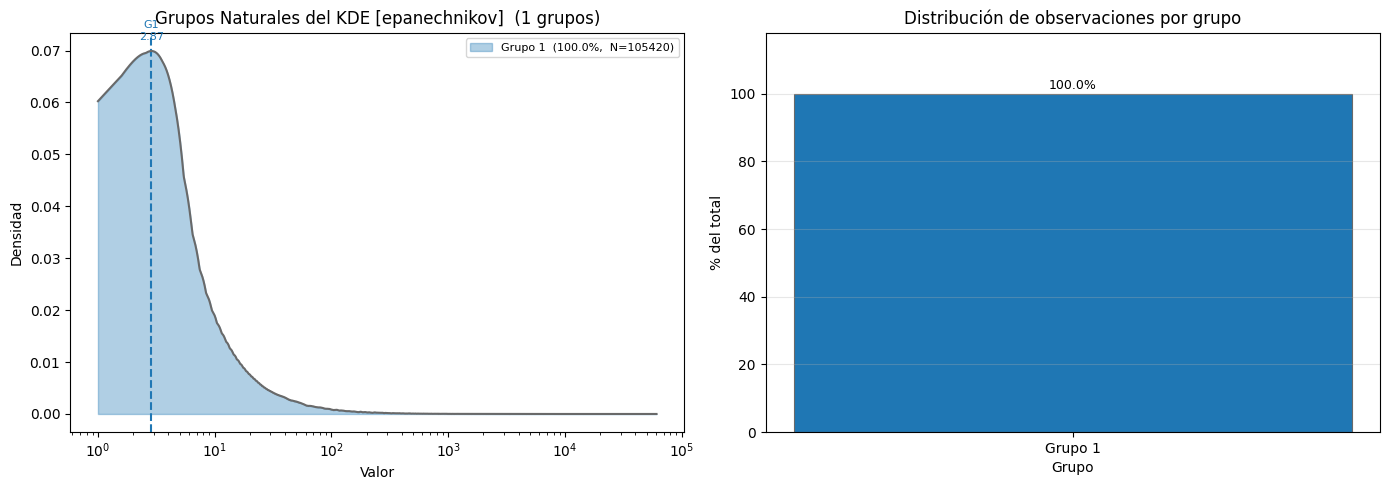

In [9]:
# =========================================
# 7) Grupos Naturales Emergentes del KDE
# =========================================
from scipy.signal import find_peaks

# -----------------------------
# Parámetros de detección de picos
# -----------------------------
prominence_frac = 0.05   # mínima prominencia como fracción del pico máximo
distance_frac   = 0.02   # mínima separación entre picos (fracción del total de puntos)

prom_min = prominence_frac * y_grid.max()
dist_min = max(1, int(distance_frac * len(x_grid)))

picos_idx, _ = find_peaks(y_grid, prominence=prom_min, distance=dist_min)

if len(picos_idx) == 0:
    picos_idx = np.array([np.argmax(y_grid)])

n_grupos = len(picos_idx)

print("=" * 60)
print(f"  GRUPOS NATURALES DEL KDE  ({n_grupos} modo(s) detectado(s))")
print("=" * 60)
print(f"  Parámetros: prominence ≥ {prom_min:.4g}  |  distance ≥ {dist_min} puntos")
print()

# -----------------------------
# Fronteras: valle entre picos consecutivos
# -----------------------------
fronteras = []
for i in range(len(picos_idx) - 1):
    seg_y = y_grid[picos_idx[i]:picos_idx[i + 1]]
    seg_x = x_grid[picos_idx[i]:picos_idx[i + 1]]
    fronteras.append(float(seg_x[np.argmin(seg_y)]))

limites = [float(x_grid[0])] + fronteras + [float(x_grid[-1])]

# -----------------------------
# Estadísticas por grupo
# -----------------------------
grupos_info = []
for i in range(n_grupos):
    lo, hi = limites[i], limites[i + 1]
    mask = (data_kde >= lo) & (data_kde <= hi)
    datos_g = data_kde[mask]

    grupos_info.append({
        "grupo"  : i + 1,
        "x_peak" : float(x_grid[picos_idx[i]]),
        "y_peak" : float(y_grid[picos_idx[i]]),
        "x_lo"   : lo,
        "x_hi"   : hi,
        "n"      : len(datos_g),
        "pct"    : 100.0 * len(datos_g) / len(data_kde),
        "media"  : float(np.mean(datos_g))           if len(datos_g) > 0 else np.nan,
        "mediana": float(np.median(datos_g))         if len(datos_g) > 0 else np.nan,
        "std"    : float(np.std(datos_g, ddof=1))    if len(datos_g) > 1 else np.nan,
    })

    g = grupos_info[-1]
    print(f"  Grupo {g['grupo']}:")
    print(f"    Rango     : [{g['x_lo']:.4g},  {g['x_hi']:.4g}]")
    print(f"    Pico KDE  : x = {g['x_peak']:.4g}  (densidad = {g['y_peak']:.4g})")
    print(f"    N puntos  : {g['n']}  ({g['pct']:.1f}% del total)")
    print(f"    Media     : {g['media']:.4g}")
    print(f"    Mediana   : {g['mediana']:.4g}")
    print(f"    Std       : {g['std']:.4g}")
    if i < n_grupos - 1:
        print(f"    Frontera  → {fronteras[i]:.4g}  (valle hacia grupo {i + 2})")
    print()

print("=" * 60)

# -----------------------------
# Visualización
# -----------------------------
colores_g = plt.cm.tab10(np.linspace(0, 0.9, n_grupos))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: KDE sombreado por grupos
ax = axes[0]
for i, g in enumerate(grupos_info):
    mask_plot = (x_grid >= g["x_lo"]) & (x_grid <= g["x_hi"])
    ax.fill_between(x_grid, y_grid, where=mask_plot,
                    alpha=0.35, color=colores_g[i],
                    label=f"Grupo {g['grupo']}  ({g['pct']:.1f}%,  N={g['n']})")
    ax.axvline(g["x_peak"], color=colores_g[i], linestyle="--", linewidth=1.5)
    ax.annotate(f"G{g['grupo']}\n{g['x_peak']:.3g}",
                xy=(g["x_peak"], g["y_peak"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8, color=colores_g[i])

for xf in fronteras:
    ax.axvline(xf, color="black", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Valle: {xf:.3g}" if xf == fronteras[0] else "_nolegend_")

ax.plot(x_grid, y_grid, linewidth=1.5, color="dimgray")

if usar_escala_log_x:
    ax.set_xscale("log")
ax.set_title(f"Grupos Naturales del KDE [{KERNEL}]  ({n_grupos} grupos)")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.legend(fontsize=8, loc="upper right")

# Panel derecho: % de datos por grupo (barras)
ax2 = axes[1]
labels_g = [f"Grupo {g['grupo']}" for g in grupos_info]
pcts     = [g["pct"] for g in grupos_info]
bars = ax2.bar(labels_g, pcts, color=colores_g, edgecolor="dimgray", linewidth=0.8)
for bar, pct in zip(bars, pcts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax2.set_title("Distribución de observaciones por grupo")
ax2.set_xlabel("Grupo")
ax2.set_ylabel("% del total")
ax2.set_ylim(0, max(pcts) * 1.18)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8) Comparación de todos los Kernels

Se visualizan las 6 estimaciones de densidad lado a lado usando el mismo `bw_method` para todos los kernels, permitiendo comparar la forma que cada kernel impone a la distribución.

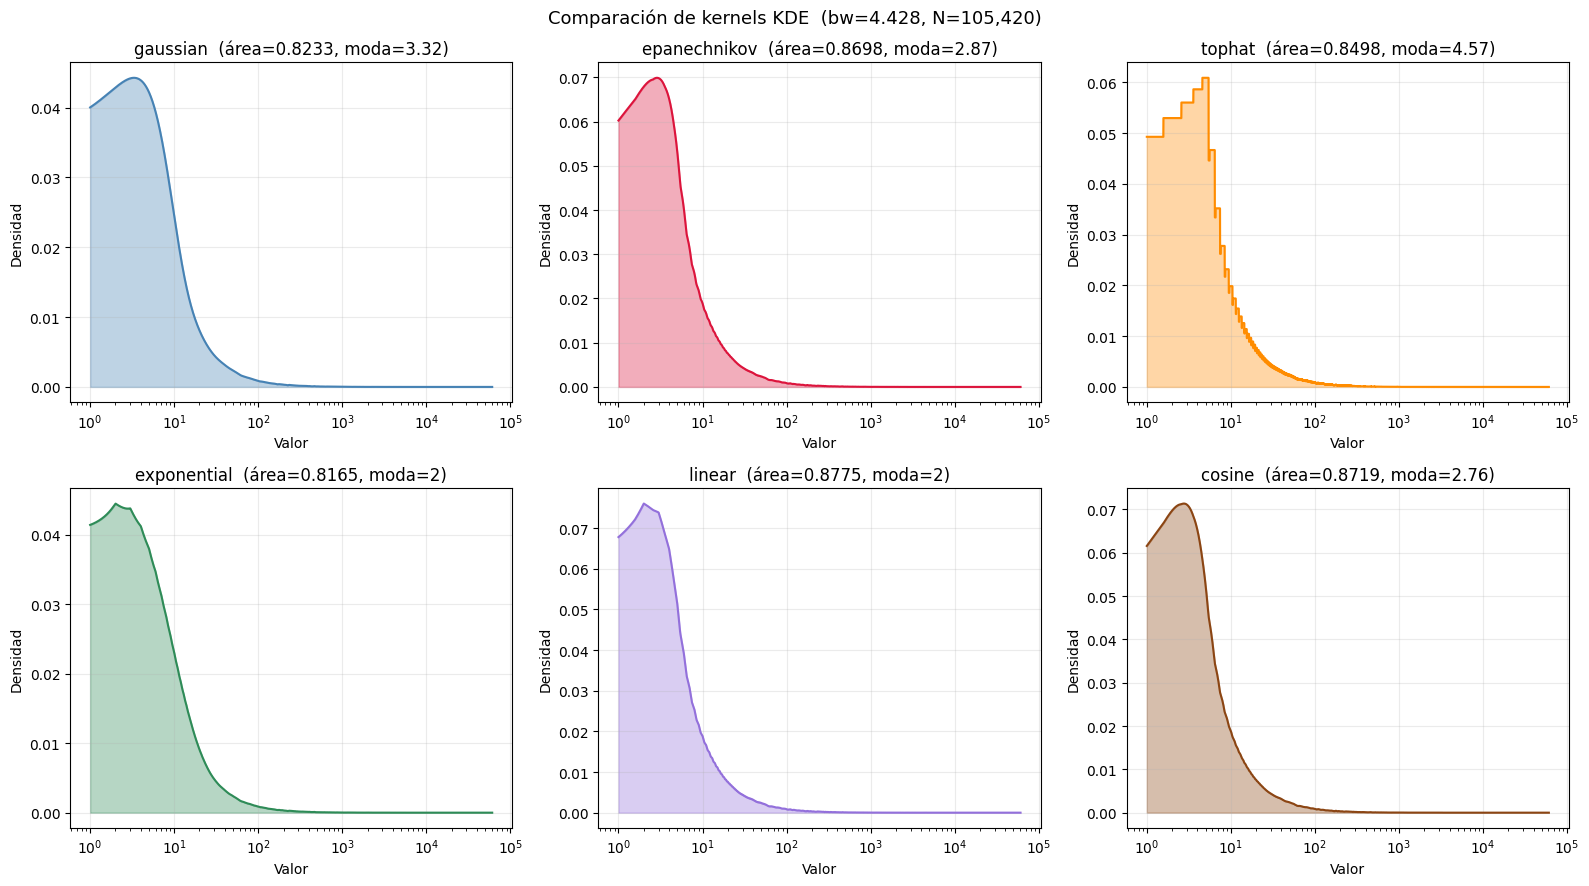

In [10]:
# =========================================
# 8) Comparación de todos los kernels
# =========================================
KERNELS_COMP = ['gaussian', 'epanechnikov', 'tophat', 'exponential', 'linear', 'cosine']
colores_comp = ['steelblue', 'crimson', 'darkorange', 'seagreen', 'mediumpurple', 'saddlebrown']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"Comparación de kernels KDE  (bw={bw_method:.4g}, N={len(data_kde):,})", fontsize=13)

for ax, kernel, color in zip(axes.ravel(), KERNELS_COMP, colores_comp):
    _kde_comp = KernelDensity(kernel=kernel, bandwidth=bw_method)
    _kde_comp.fit(data_kde.reshape(-1, 1))
    _y_comp = np.exp(_kde_comp.score_samples(x_grid.reshape(-1, 1)))
    ax.fill_between(x_grid, _y_comp, alpha=0.35, color=color)
    ax.plot(x_grid, _y_comp, color=color, linewidth=1.5)
    if usar_escala_log_x:
        ax.set_xscale("log")
    area = float(np.trapezoid(_y_comp, x_grid))
    moda = float(x_grid[np.argmax(_y_comp)])
    ax.set_title(f"{kernel}  (área={area:.4f}, moda={moda:.3g})")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 9) Sanity check: sklearn(gaussian) == scipy.gaussian_kde

Verificamos que la ruta sklearn (usada para todos los kernels) reproduce el resultado de `scipy.stats.gaussian_kde` (usado en el notebook original single-kernel) cuando `kernel='gaussian'` y el mismo bandwidth Scott. Si esto se cumple, toda la maquinaria multikernel es matem?ticamente consistente con el notebook original.


In [11]:
# Sanity check: sklearn gaussian con bw Scott == scipy.gaussian_kde
_kde_scipy = gaussian_kde(data_kde, bw_method="scott")
_y_scipy   = _kde_scipy(x_grid)

_kde_sk_g  = KernelDensity(kernel="gaussian", bandwidth=_bw_scott_abs).fit(data_kde.reshape(-1, 1))
_y_sk_g    = np.exp(_kde_sk_g.score_samples(x_grid.reshape(-1, 1)))

_max_diff = float(np.max(np.abs(_y_scipy - _y_sk_g)))
_rel_diff = _max_diff / float(np.max(_y_scipy))
_moda_sci = float(x_grid[np.argmax(_y_scipy)])
_moda_sk  = float(x_grid[np.argmax(_y_sk_g)])
_area_sci = float(np.trapezoid(_y_scipy, x_grid))
_area_sk  = float(np.trapezoid(_y_sk_g,  x_grid))

print("="*60)
print("SANITY CHECK ? sklearn(gaussian) vs scipy.gaussian_kde")
print("="*60)
print(f"  bw Scott (absoluto)        = {_bw_scott_abs:.6g}")
print(f"  max|scipy - sklearn|       = {_max_diff:.2e}")
print(f"  diferencia relativa (%)    = {100*_rel_diff:.2e}")
print(f"  Moda  scipy  = {_moda_sci:.4g}")
print(f"  Moda  sklearn= {_moda_sk:.4g}")
print(f"  Area  scipy  = {_area_sci:.4f}")
print(f"  Area  sklearn= {_area_sk:.4f}")
print("="*60)
assert _rel_diff < 1e-4, f"Discrepancia inesperada: rel_diff={_rel_diff:.2e}"
print("OK: sklearn(gaussian) reproduce scipy.gaussian_kde; la maquinaria multikernel es consistente.")


SANITY CHECK ? sklearn(gaussian) vs scipy.gaussian_kde
  bw Scott (absoluto)        = 88.5675
  max|scipy - sklearn|       = 2.12e-14
  diferencia relativa (%)    = 5.53e-10
  Moda  scipy  = 16.57
  Moda  sklearn= 16.57
  Area  scipy  = 0.6195
  Area  sklearn= 0.6195
OK: sklearn(gaussian) reproduce scipy.gaussian_kde; la maquinaria multikernel es consistente.
